<a href="https://colab.research.google.com/github/RicheTasnim/MachineLearning/blob/main/Forecasting_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ARIMA



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
import itertools

warnings.filterwarnings('ignore')

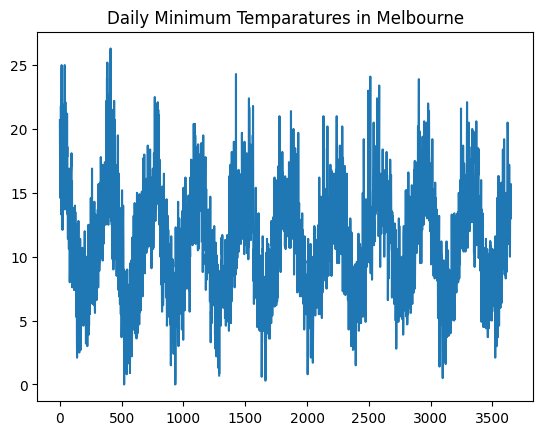

In [ ]:
# Loading the dataset

data = pd.read_csv('/content/daily-min-temperatures.csv')
data['Temp'] = pd.to_numeric(data['Temp'], errors='coerce')
ts = data['Temp']

ts.plot(title='Daily Minimum Temparatures in Melbourne')
plt.show()

In [ ]:
# Stationarity Check(ADF Test)

ts = ts.dropna()
result = adfuller(ts)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

if result[1] > 0.05:
  print("Series is non stationary; differencing is needed.")

else:
  print("Series is stationary; no differencing needed.")

ADF Statistic: -4.444653
p-value: 0.000247
Series is stationary; no differencing needed.


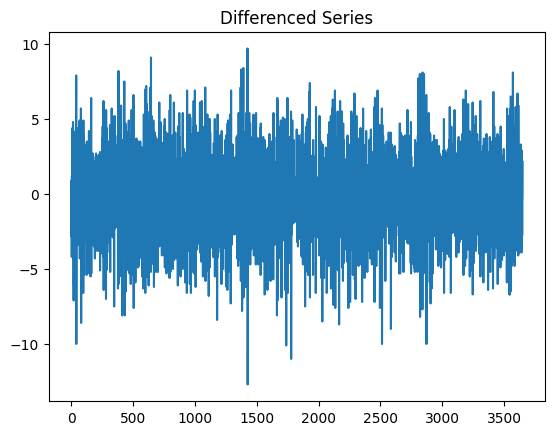

ADF Statistic (differenced): -21.079000
p-value (differenced): 0.000000


In [ ]:
# Differencing to Achieve Stationary

ts_diff = ts.diff().dropna()

ts_diff.plot(title='Differenced Series')
plt.show()

result_diff = adfuller(ts_diff)
print('ADF Statistic (differenced): %f' % result_diff[0])
print('p-value (differenced): %f' % result_diff[1])

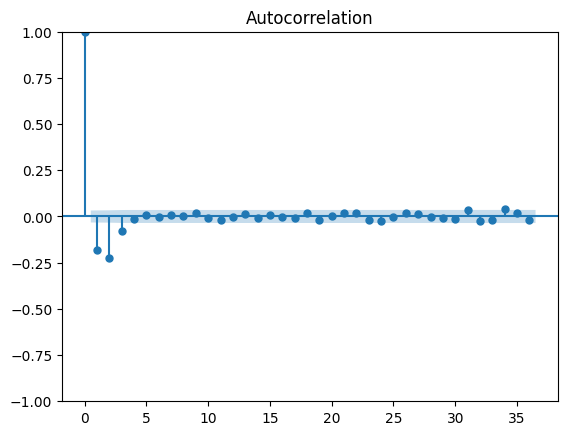

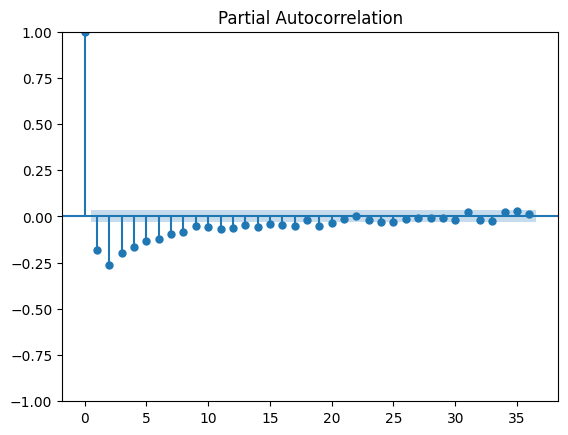

In [ ]:
# ACF and PACF Plotting (Model Order Identification)

plot_acf(ts_diff)
plt.show()

plot_pacf(ts_diff)
plt.show()

In [ ]:
# ARIMA Model Selection Using Grid Search

p = range(0, 4)
d = range(0, 3)
q = range(0, 4)
pdq = list(itertools.product(p, d, q))

best_aic = np.inf
best_order = None
best_model = None

for order in pdq:
  try:
    model = ARIMA(ts, order=order)
    results = model.fit()
    if results.aic < best_aic:
      best_aic = results.aic
      best_order = order
      best_model = results

  except:
    continue

print(f'Best ARIMA order: {best_order} with AIC: {best_aic}')

Best ARIMA order: (3, 0, 1) with AIC: 16760.85769987077


In [ ]:
# Model fitting and forecasting

final_model = ARIMA(ts, order=best_order)
results = final_model.fit()

forecast_values = results.forecast(steps=10)

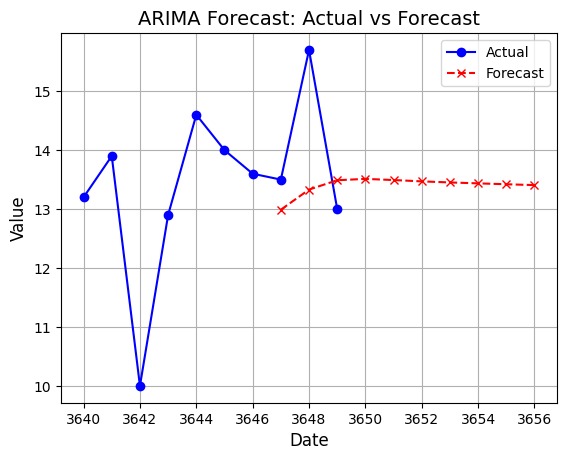

In [ ]:
from matplotlib.lines import lineStyles
# Model Evaluation

plt.plot(ts[-10:].index, ts[-10:], label='Actual',
         color='blue', linestyle='-', marker='o')
plt.plot(forecast_values.index, forecast_values, label='Forecast', color='red', linestyle='--', marker='x')

plt.title('ARIMA Forecast: Actual vs Forecast', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

### SARIMA

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
# Loading the Dataset

df = pd.read_csv("/content/Dataset- Superstore (2015-2018).csv")
sales_data = df[['Order Date', 'Sales']]

sales_data['Order Date'] = pd.to_datetime(sales_data['Order Date'])
sales_data.head()

/tmp/ipykernel_46557/896004851.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales_data['Order Date'] = pd.to_datetime(sales_data['Order Date'])


,Order Date,Sales
0,2016-11-08,261.9600
1,2016-11-08,731.9400
2,2016-06-12,14.6200
3,2015-10-11,957.5775
4,2015-10-11,22.3680


In [4]:
# Extracting Monthly Sales

df1 = sales_data.set_index('Order Date')
monthly_sales = df1.resample('ME').sum()
monthly_sales.head()

,Sales
Order Date,
2014-01-31,14236.895
2014-02-28,4519.892
2014-03-31,55691.009
2014-04-30,28295.345
2014-05-31,23648.287


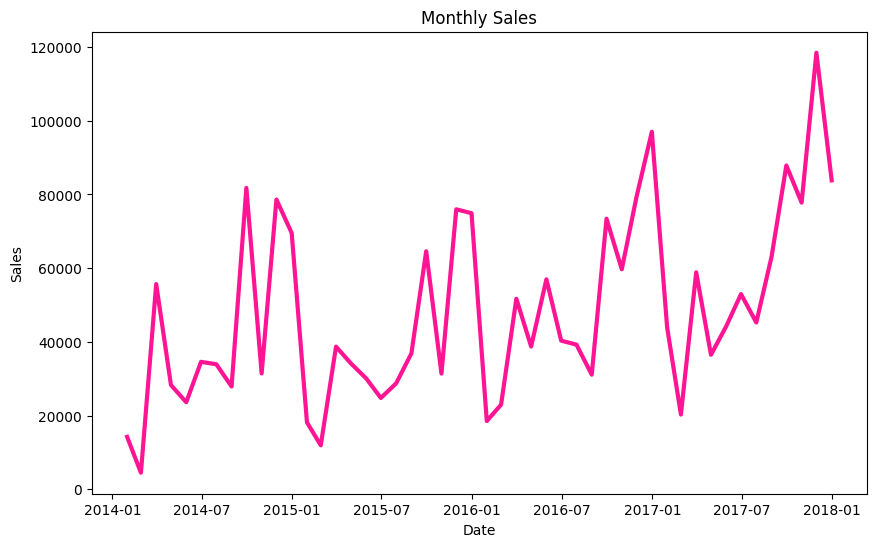

In [5]:
# Plotting the monthly sales

plt.figure(figsize=(10, 6))
plt.plot(monthly_sales['Sales'], linewidth=3, c='deeppink')
plt.title("Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [8]:
# Stationarity Check

def check_stationarity(timeseries):
    result = adfuller(timeseries, autolag='AIC')
    p_value = result[1]
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {p_value}')
    print('Stationary' if p_value < 0.05 else 'Non-Stationary')


check_stationarity(monthly_sales['Sales'])

ADF Statistic: -4.493767844002665
p-value: 0.00020180198458237758
Stationary


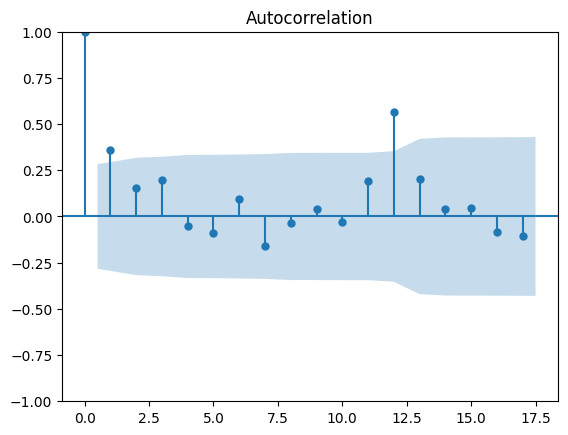

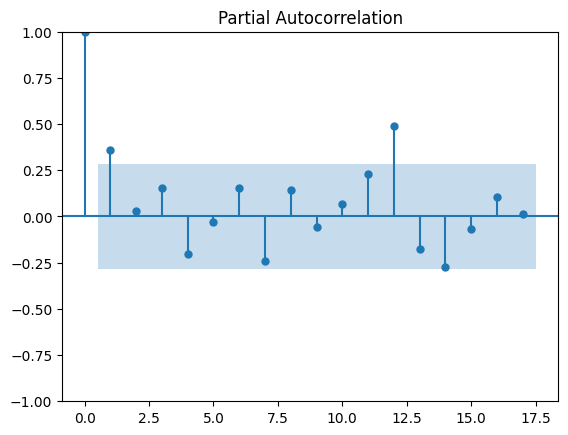

In [9]:
# Identifying model parameters

plot_acf(monthly_sales)
plot_pacf(monthly_sales)
plt.show()

In [10]:
# Fitting the SARIMA Model

p, d, q = 1, 1, 1
P, D, Q, s = 1, 1, 1, 12

model = SARIMAX(monthly_sales, order=(p, d, q),
                seasonal_order=(P, D, Q, s))
results = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


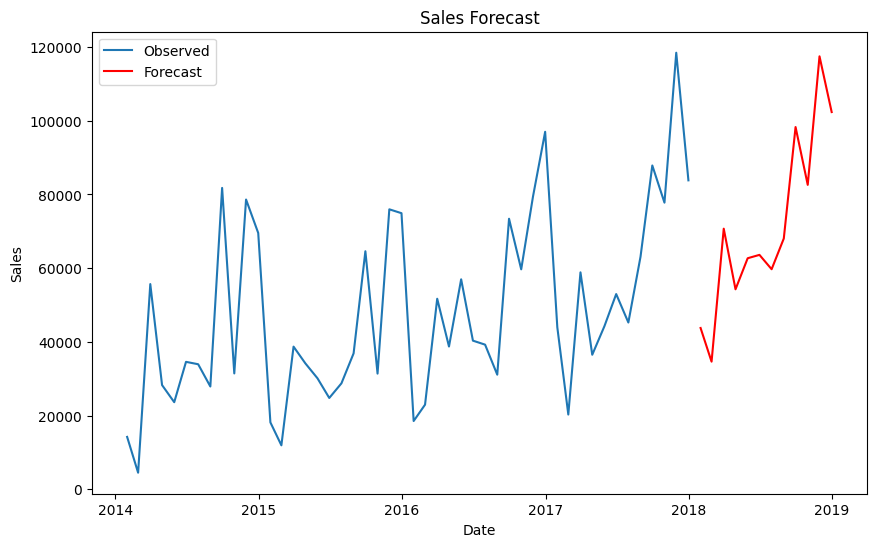

In [12]:
# Generating forecasts

forecast_periods = 12
forecast = results.forecast(steps=forecast_periods)

plt.figure(figsize=(10, 6))
plt.plot(monthly_sales, label='Observed')
plt.plot(forecast, label='Forecast', color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

In [13]:
# Evaluating the Model
# Take last 12 months as observed values

observed = monthly_sales.tail(forecast_periods)

mae = mean_absolute_error(observed, forecast)
mse = mean_squared_error(observed, forecast)

print("MAE: ", mae)
print("MSE: ", mse)

MAE:  10611.591984026598
MSE:  151953342.15188608
